In [1]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

### Load the Data
Adjust the `OUTPUT_PATH` if needed. The dates are extracted from the `timestamp_absolute` column (which is in epoch milliseconds).

In [2]:
OUTPUT_PATH = '../outputs/fastStorage_m3sa/raw-output/0/seed=0'

# Load Host metrics
host_file = os.path.join(OUTPUT_PATH, 'host.parquet')
if os.path.exists(host_file):
    df_host = pq.read_table(host_file).to_pandas()
    # Convert epoch milliseconds to datetime
    df_host['datetime'] = pd.to_datetime(df_host['timestamp_absolute'], unit='ms')
    print(f"Loaded {len(df_host)} host records.")
else:
    print(f"Could not find {host_file}")

# Load Task metrics
task_file = os.path.join(OUTPUT_PATH, 'task.parquet')
if os.path.exists(task_file):
    df_task = pq.read_table(task_file).to_pandas()
    df_task['datetime'] = pd.to_datetime(df_task['timestamp_absolute'], unit='ms')
    print(f"Loaded {len(df_task)} task records.")
else:
    print(f"Could not find {task_file}")

Loaded 28026 host records.
Loaded 125181 task records.


### Plot Cluster CPU Usage Over Time
Aggregating CPU usage and limits across all hosts in a cluster.

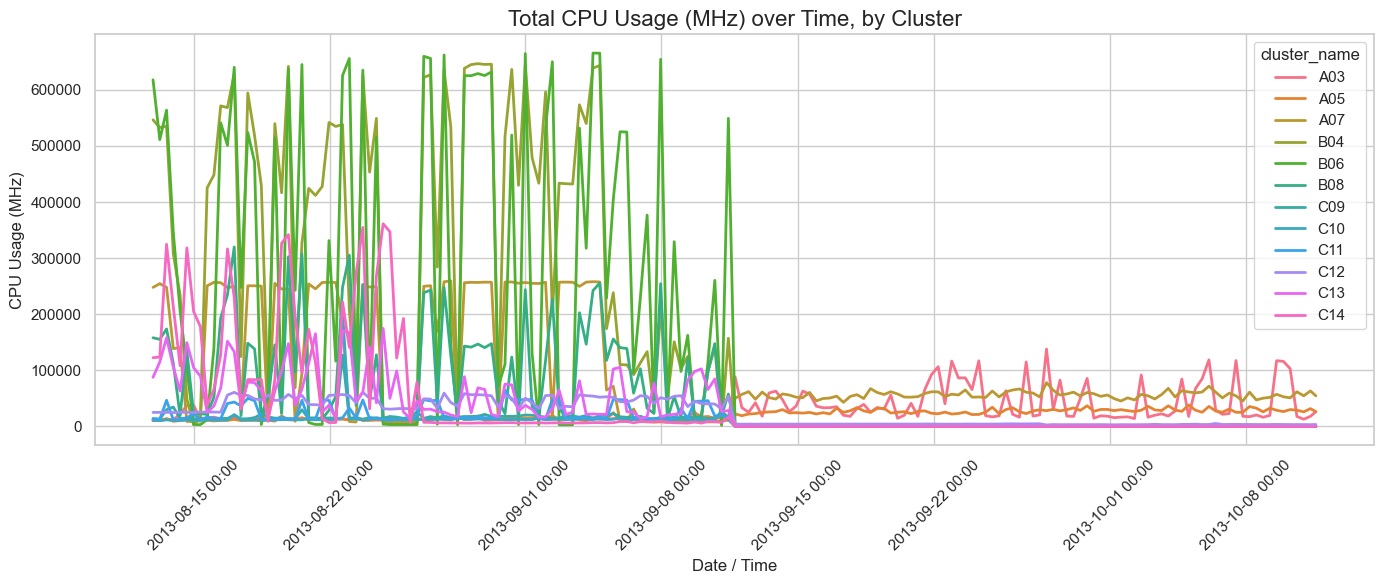

In [3]:
if 'df_host' in locals():
    # Aggregate metrics by time and cluster
    cluster_metrics = df_host.groupby(['datetime', 'cluster_name'])[['cpu_usage', 'cpu_capacity']].sum().reset_index()

    fig, ax = plt.subplots()

    # Plot usage per cluster
    sns.lineplot(data=cluster_metrics, x='datetime', y='cpu_usage', hue='cluster_name', ax=ax, linewidth=2)

    # Format the x-axis to show dates nicely
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)

    plt.title('Total CPU Usage (MHz) over Time, by Cluster', fontsize=16)
    plt.ylabel('CPU Usage (MHz)', fontsize=12)
    plt.xlabel('Date / Time', fontsize=12)
    plt.tight_layout()
    plt.show()

### Plot Total Power Draw Over Time

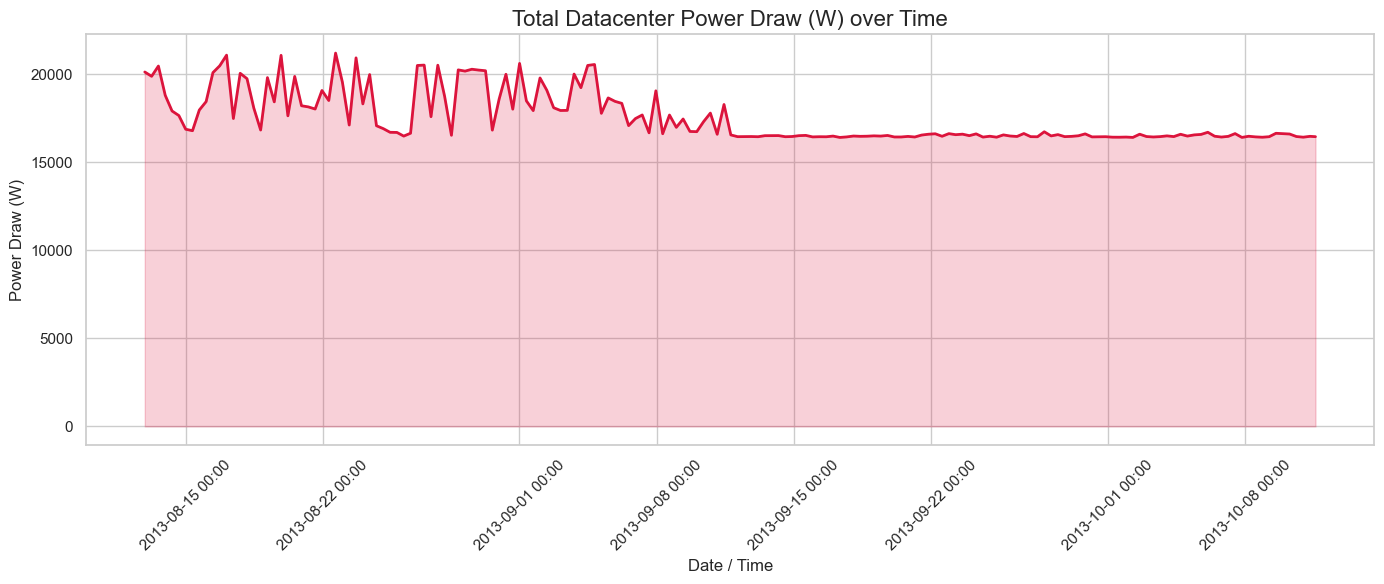

In [4]:
if 'df_host' in locals():
    # Aggregate power across all hosts
    datacenter_power = df_host.groupby('datetime')['power_draw'].sum().reset_index()

    fig, ax = plt.subplots()

    sns.lineplot(data=datacenter_power, x='datetime', y='power_draw', ax=ax, color='crimson', linewidth=2)

    # Format the x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)

    plt.title('Total Datacenter Power Draw (W) over Time', fontsize=16)
    plt.ylabel('Power Draw (W)', fontsize=12)
    plt.xlabel('Date / Time', fontsize=12)
    plt.fill_between(datacenter_power['datetime'], datacenter_power['power_draw'], alpha=0.2, color='crimson')
    plt.tight_layout()
    plt.show()

### Task Count Over Time

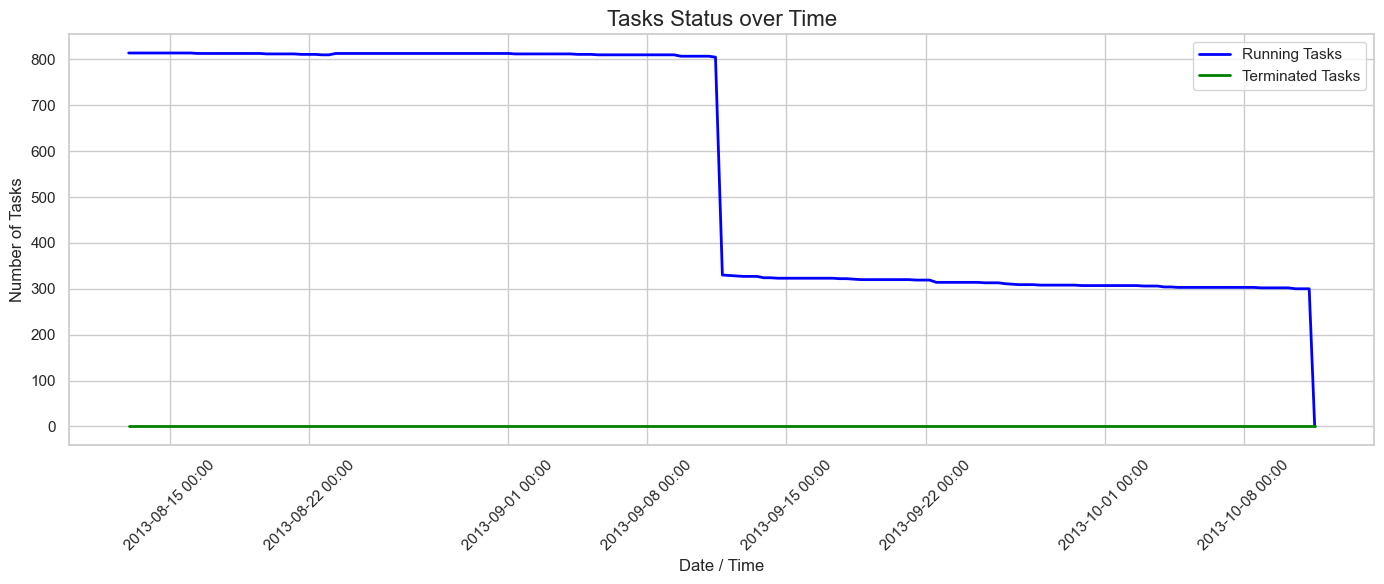

In [5]:
if 'df_host' in locals():
    # Task states are easily tracked by summing running/terminated stats from hosts
    task_stats = df_host.groupby('datetime')[['tasks_running', 'tasks_terminated']].sum().reset_index()

    fig, ax = plt.subplots()

    sns.lineplot(data=task_stats, x='datetime', y='tasks_running', label='Running Tasks', color='blue', linewidth=2)
    sns.lineplot(data=task_stats, x='datetime', y='tasks_terminated', label='Terminated Tasks', color='green', linewidth=2)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)

    plt.title('Tasks Status over Time', fontsize=16)
    plt.ylabel('Number of Tasks', fontsize=12)
    plt.xlabel('Date / Time', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Scheduling Delay Over Time
Many tasks experienced significant queuing delays waiting for resources. This plot shows how the scheduling delay built up over the course of the simulation.

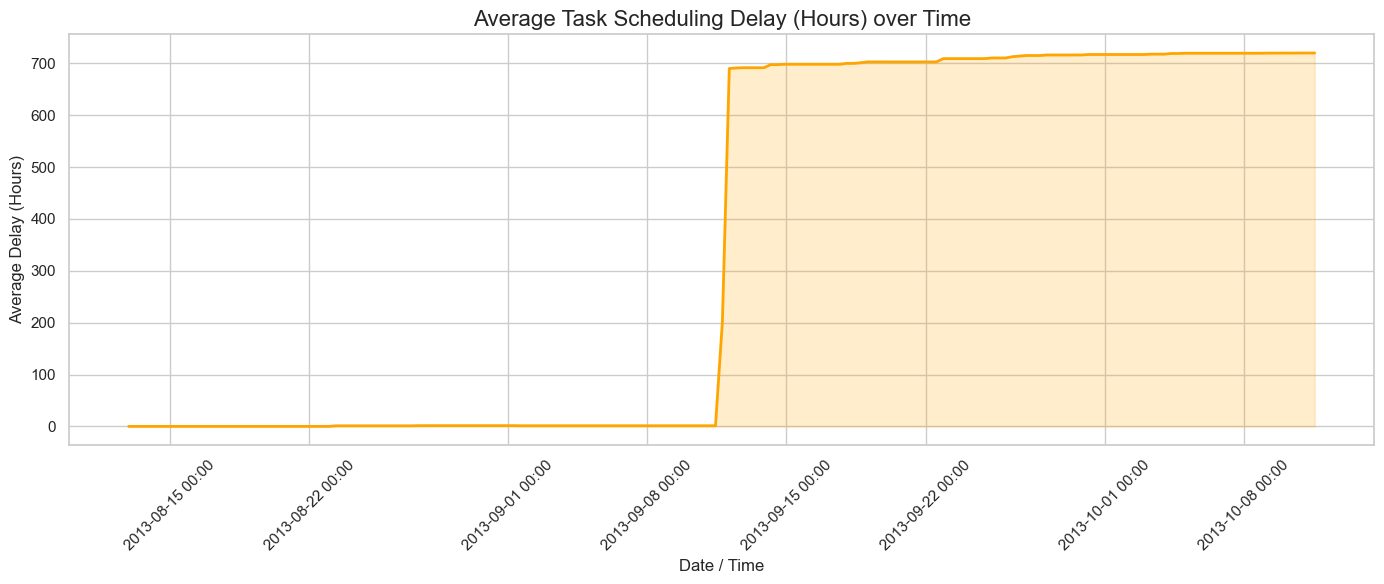

In [6]:
if 'df_task' in locals():
    # Convert scheduling delay from ms to Hours
    df_task['scheduling_delay_hours'] = df_task['scheduling_delay'] / (1000 * 3600)
    delay_stats = df_task.groupby('datetime')['scheduling_delay_hours'].mean().reset_index()

    fig, ax = plt.subplots()

    sns.lineplot(data=delay_stats, x='datetime', y='scheduling_delay_hours', color='orange', linewidth=2)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)

    plt.title('Average Task Scheduling Delay (Hours) over Time', fontsize=16)
    plt.ylabel('Average Delay (Hours)', fontsize=12)
    plt.xlabel('Date / Time', fontsize=12)
    plt.fill_between(delay_stats['datetime'], delay_stats['scheduling_delay_hours'], alpha=0.2, color='orange')
    plt.tight_layout()
    plt.show()